# Helical acquisition and reconstruction testing

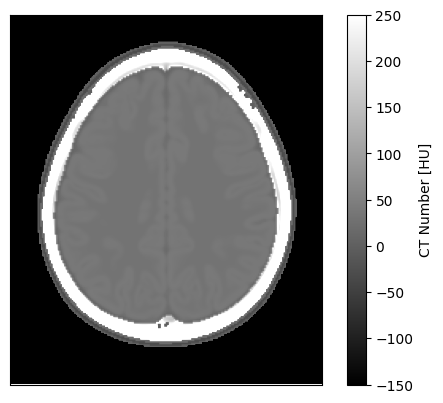

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from insilicoICH.ground_truth_definition.phantoms import NIHPD_Head

from utils import ctshow

nihpd_dir = Path('../phantom_dir/NIHPD_Head_Phantom')
nihpd = NIHPD_Head(nihpd_dir, age=11.5)

im = ctshow(nihpd.get_CT_number_phantom()[80])
plt.colorbar(im, label='CT Number [HU]')

In [2]:
from insilicoICH.image_acquisition import Scanner

nihpd.patient_name = 'helical_test'
scanner = Scanner(nihpd)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing helical_test/phantoms/0/0_ncat_ad


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

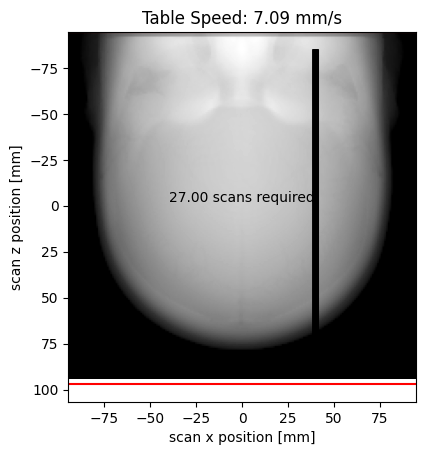

In [3]:
scanner.scout_view(pitch=1)

In [4]:
import numpy as np
import pandas as pd

In [5]:
views = 100
scanner.rotations_per_scan(), views, np.ceil(views*scanner.rotations_per_scan())

(np.float64(26.9999902878034), 100, np.float64(2700.0))

Check that the total number of views is what you'd expect based on the number of rotations and views per rotation:

In [6]:
scanner.run_scan(pitch=1, views=views)

Airscan
Offset scan
Phantom scan


  0%|          | 0/2700 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.


  0%|          | 1/2700 [00:02<1:43:27,  2.30s/it]

in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 2700/2700 [09:43<00:00,  4.63it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [7]:
scanner.run_recon()

fov size: 250.0
* Loading the projection data...


* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/191...
   recon slice 1/191...
   recon slice 2/191...
   recon slice 3/191...
   recon slice 4/191...
   recon slice 5/191...
   recon slice 6/191...
   recon slice 7/191...
   recon slice 8/191...
   recon slice 9/191...
   recon slice 10/191...
   recon slice 11/191...
   recon slice 12/191...
   recon slice 13/191...
   recon slice 14/191...
   recon slice 15/191...
   recon slice 16/191...
   recon slice 17/191...
   recon slice 18/191...
   recon slice 19/191...
   recon slice 20/191...
   recon slice 21/191...
   recon slice 22/191...
   recon slice 23/191...
   recon slice 24/191...
   recon slice 25/191...
   recon slice 26/191...
   recon slice 27/191...
   recon slice 28/191...
   recon slice 29/191...
   recon slice 30/191...
   recon slice 31/191...
   recon slice 32/191...
   recon


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (191, 512, 512) 25.0 cm fov
Projections: (2700, 16, 900)

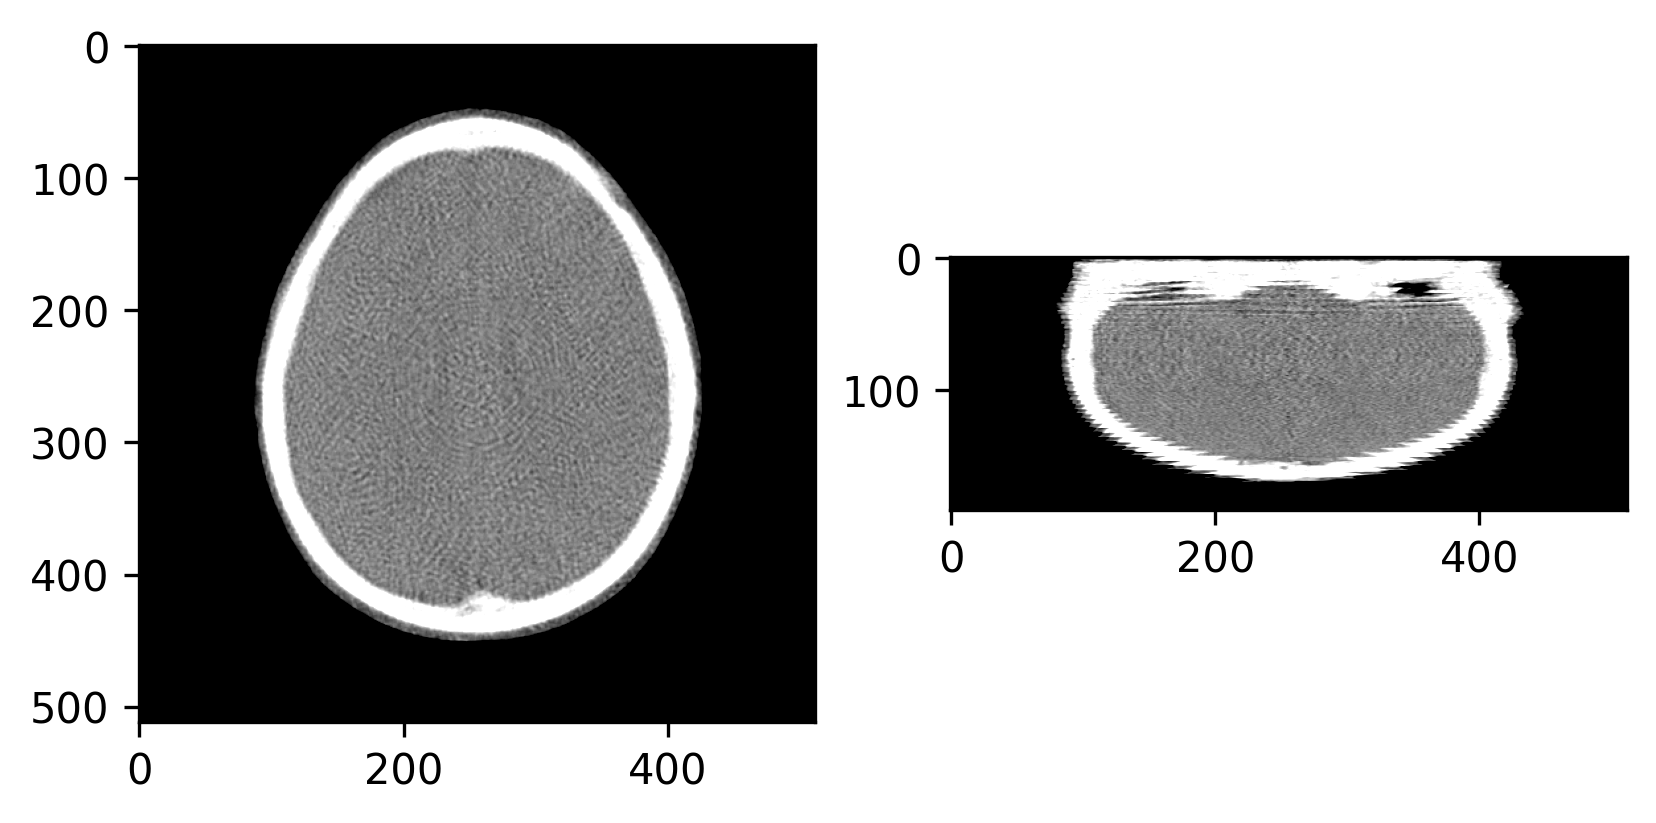

In [16]:
ww, wl = 300, 30
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[100], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

In [18]:
scanner.run_scan(pitch=0, views=views)

scan: 1/27
Airscan


FileNotFoundError: [Errno 2] No such file or directory: '/home/brandon.nelson/Dev/PedSilicoICH/notebooks/helical_test/simulations/0/000_/home/brandon.nelson/Dev/PedSilicoICH/notebooks/helical_test/simulations/0/200mA_120kV.air'

In [9]:
scanner.xcist.cfg.protocol.viewsPerRotation = 100
scanner.xcist.cfg.protocol.startZ = -75
endZ = 75
scanner.xcist.cfg.recon.sliceThickness = 1
scanner.xcist.cfg.protocol.rotationTime = 1
scanner.pitch = 1

# scanner.xcist.cfg.scanner.detectorRowCount = 64

# do not edit below
table_feed_per_rotation = scanner.pitch*scanner.scan_width

scanner.calculate_start_positions()
scanner.xcist.cfg.protocol.scanTrajectory = "Gantry_Helical"

scanner.xcist.cfg.protocol.spectrumFilename = "xcist_kVp120_tar7_bin1.dat"

exam_range = endZ - scanner.xcist.cfg.protocol.startZ
table_feed_per_rotation = scanner.scan_width * scanner.pitch # distance covered in mm in a 360 degree scan rotation
rotations = exam_range / table_feed_per_rotation

scanner.xcist.cfg.protocol.viewCount = np.ceil(scanner.xcist.cfg.protocol.viewsPerRotation*rotations).astype(int)
scanner.xcist.cfg.protocol.stopViewId = scanner.xcist.cfg.protocol.startViewId+scanner.xcist.cfg.protocol.viewCount-1

scan_duration = rotations * scanner.xcist.cfg.protocol.rotationTime
scanner.xcist.cfg.protocol.tableSpeed = exam_range / scan_duration

pd.DataFrame({'exam range [mm]': [exam_range], #  total scan coverage after all rotations
              'scan range [mm]': [scanner.scan_width], #  scan coverage after a single rotation
              'scan duration [s]': [scan_duration],
              'rotations': [rotations],
              'view count': [scanner.xcist.cfg.protocol.viewCount],
              'table speed [mm/s]': [scanner.xcist.cfg.protocol.tableSpeed]})

,exam range [mm],scan range [mm],scan duration [s],rotations,view count,table speed [mm/s]
0,150,7.094737,21.142433,21.142433,2115,7.094737


In [11]:
sliceCount = int(exam_range / scanner.xcist.cfg.recon.sliceThickness)
scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
scanner.xcist.cfg.recon.sliceCount = sliceCount
scanner


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (191, 512, 512) 25.0 cm fov
Projections: (2700, 16, 900)

In [12]:
scanner.xcist.run_all()

Airscan
Offset scan
Phantom scan


  0%|          | 0/2115 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 2115/2115 [07:43<00:00,  4.56it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.


In [13]:
from gecatsim.reconstruction.pyfiles import recon
vol = recon.recon_direct(scanner.xcist.cfg).transpose(2, 0, 1)
vol.shape

* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/150...
   recon slice 1/150...
   recon slice 2/150...
   recon slice 3/150...
   recon slice 4/150...
   recon slice 5/150...
   recon slice 6/150...
   recon slice 7/150...
   recon slice 8/150...
   recon slice 9/150...
   recon slice 10/150...
   recon slice 11/150...
   recon slice 12/150...
   recon slice 13/150...
   recon slice 14/150...
   recon slice 15/150...
   recon slice 16/150...
   recon slice 17/150...
   recon slice 18/150...
   recon slice 19/150...
   recon slice 20/150...
   recon slice 21/150...
   recon slice 22/150...
   recon slice 23/150...
   recon slice 24/150...
   recon slice 25/150...
   recon slice 26/150...
   recon slice 27/150...
   recon slice 28/150...
   recon slice 29/150...
   recon slice 30/150...
   recon slice 31/150...


(150, 512, 512)

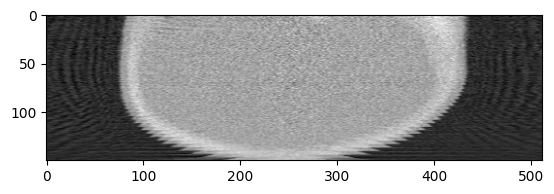

In [14]:
ww, wl = 300, 30
disp = dict(cmap='gray')
plt.imshow(vol[:, 256], **disp)